<a href="https://colab.research.google.com/github/commitwizard-14/Machine-learning-files/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("/content/ScreenTime vs MentalWellness.csv")
# shape of df (400, 16)
print(df.head())
print(df.info())

  user_id  age  gender occupation  work_mode  screen_time_hours  \
0   U0001   33  Female   Employed     Remote              10.79   
1   U0002   28  Female   Employed  In-person               7.40   
2   U0003   35  Female   Employed     Hybrid               9.78   
3   U0004   42    Male   Employed     Hybrid              11.13   
4   U0005   28    Male    Student     Remote              13.22   

   work_screen_hours  leisure_screen_hours  sleep_hours  sleep_quality_1_5  \
0               5.44                  5.35         6.63                  1   
1               0.37                  7.03         8.05                  3   
2               1.09                  8.69         6.48                  1   
3               0.56                 10.57         6.89                  1   
4               4.09                  9.13         5.79                  1   

   stress_level_0_10  productivity_0_100  exercise_minutes_per_week  \
0                9.3                44.7                 

/tmp/ipython-input-2605275372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age', y='screen_time_hours', data=df,


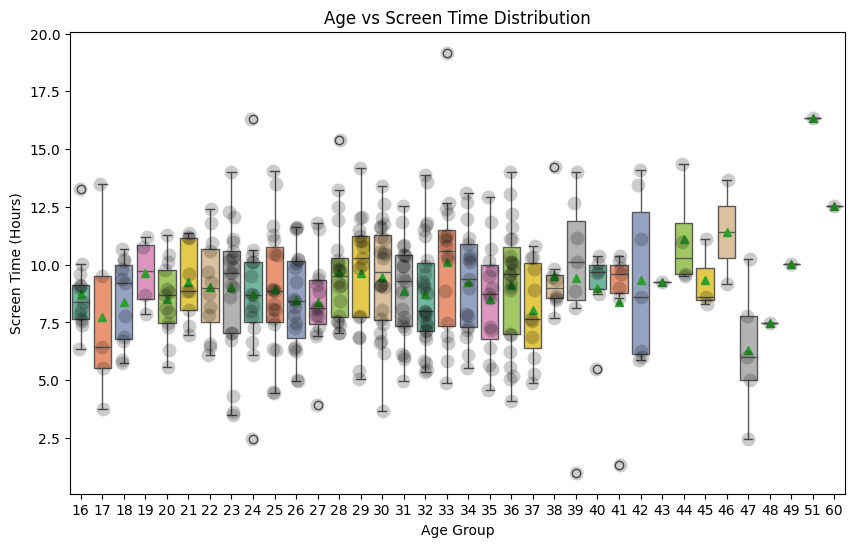

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='age', y='screen_time_hours', data=df,
            palette="Set2",showmeans=True)
sns.stripplot(data = df,x="age",y = "screen_time_hours",color="black",size=10,alpha=0.2)

plt.title("Age vs Screen Time Distribution")
plt.xlabel("Age Group")
plt.ylabel("Screen Time (Hours)")
plt.show()


**Occupation & Screen Habits How do students, professionals, and freelancers differ in their work vs leisure screen hours?**

/tmp/ipython-input-3586283955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x= "occupation",y = "work_screen_hours",showmeans=True,
/tmp/ipython-input-3586283955.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="occupation",y= "leisure_screen_hours",showmeans=True,


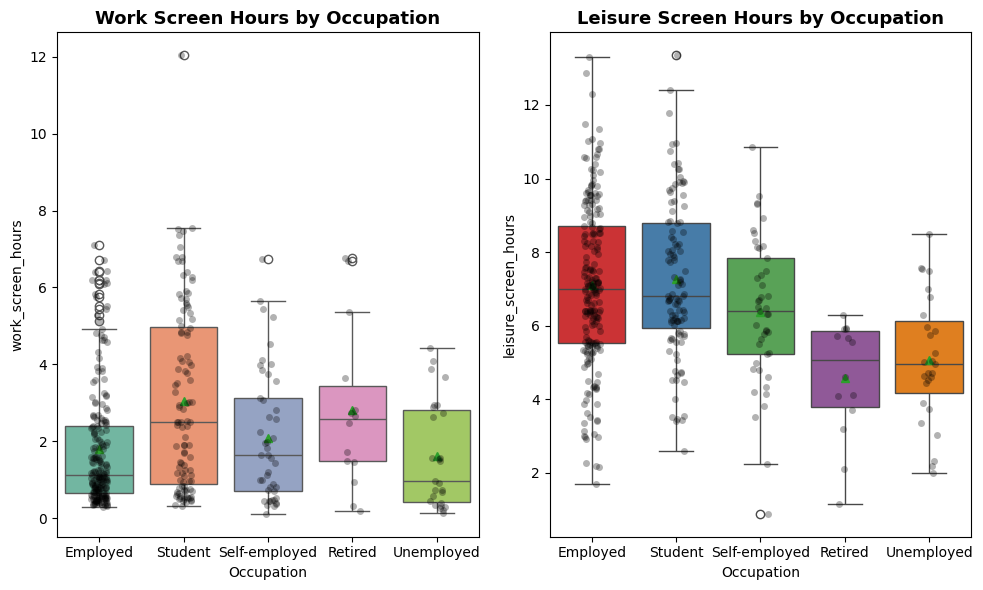

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
# work screen hours by occupation

sns.boxplot(data = df, x= "occupation",y = "work_screen_hours",showmeans=True,
            palette="Set2")
sns.stripplot(data=df,x="occupation", y = "work_screen_hours",
              size=5,alpha=0.3,color='black')
plt.xlabel("Occupation")
plt.ylabel("work_screen_hours")
plt.title("Work Screen Hours by Occupation", fontsize=13, fontweight="bold")

# 2nd chart
plt.subplot(1,2,2)

sns.boxplot(data=df,x="occupation",y= "leisure_screen_hours",showmeans=True,
            palette="Set1")
sns.stripplot(data= df ,x="occupation",y="leisure_screen_hours",
              color="black",size=5,alpha=0.3)
plt.xlabel("Occupation")
plt.ylabel("leisure_screen_hours")
plt.title("Leisure Screen Hours by Occupation", fontsize=13, fontweight="bold")


plt.tight_layout()
plt.show()


**Screen time vs Sleep**

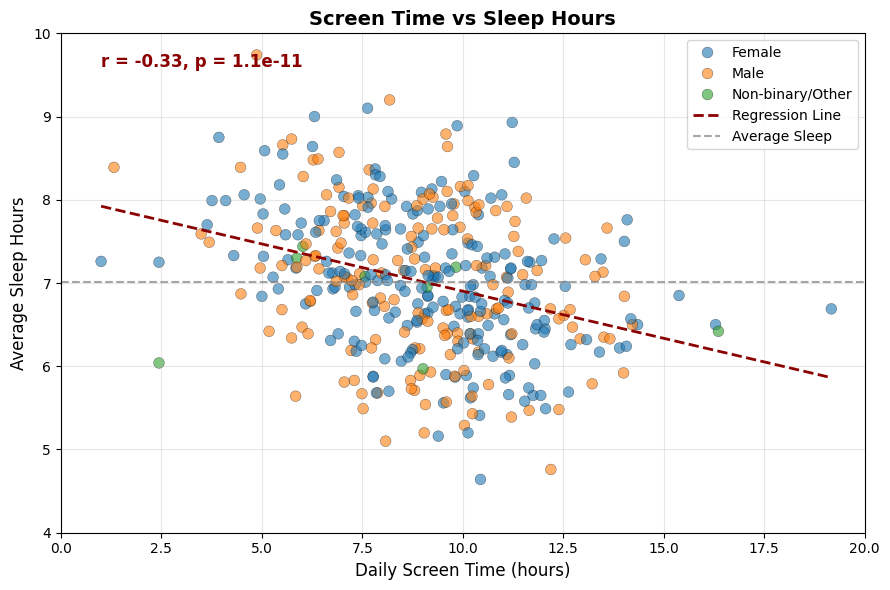

In [ ]:
plt.figure(figsize=(9,6))

# Scatterplot with points colored by gender
sns.scatterplot(
    data=df,
    x="screen_time_hours",
    y="sleep_hours",
    hue="gender",      # Differentiate by gender
    alpha=0.6,
    s=60,
    edgecolor="k",
    linewidth=0.3
)

# Add global regression line
sns.regplot(
    data=df,
    x="screen_time_hours",
    y="sleep_hours",
    scatter=False,
    color="darkred",
    ci=None,
    line_kws={"lw":2, "ls":"--"},
    label="Regression Line"
)

# Calculate Pearson correlation
r, p = pearsonr(df["screen_time_hours"], df["sleep_hours"])
plt.text(1, 9.6, f"r = {r:.2f}, p = {p:.2g}",
         fontsize=12, color="darkred", fontweight="bold")

# Add horizontal line showing the average sleep hours
plt.axhline(df["sleep_hours"].mean(),
            color="gray", ls="--", lw=1.5, alpha=0.7, label="Average Sleep")

# Axis and style adjustments
plt.xlim(0, 20)   # set screen time range
plt.ylim(4, 10)   # set sleep hours range
plt.title("Screen Time vs Sleep Hours", fontsize=14, fontweight="bold")
plt.xlabel("Daily Screen Time (hours)", fontsize=12)
plt.ylabel("Average Sleep Hours", fontsize=12)

# Show legend outside the plot area
plt.legend(loc="upper right", frameon=True, fontsize=10)

# Add grid and layout
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



**Preparing A Model**

In [ ]:
features = [
    "age", "gender", "occupation", "work_mode",
    "screen_time_hours", "work_screen_hours", "leisure_screen_hours",
    "sleep_hours", "sleep_quality_1_5", "stress_level_0_10",
    "productivity_0_100", "exercise_minutes_per_week", "social_hours_per_week"
]

# Construct feature matrix (X) and target vector (y)
X = df[features]
y = df["mental_wellness_index_0_100"]

# Output dataset dimensionality
print("Feature matrix (X):", X.shape)
print("Target vector (y):", y.shape)

# Output dataset
print(X.head())
print(X['occupation'].unique())

# converting categorical data
col_cat= ["gender","occupation","work_mode"]
d={}

for col in col_cat:
  lb= LabelEncoder()
  X[col]= lb.fit_transform(X[col].astype(str))
  d[col]=lb


print(X.head())

Feature matrix (X): (400, 13)
Target vector (y): (400,)
   age  gender occupation  work_mode  screen_time_hours  work_screen_hours  \
0   33  Female   Employed     Remote              10.79               5.44   
1   28  Female   Employed  In-person               7.40               0.37   
2   35  Female   Employed     Hybrid               9.78               1.09   
3   42    Male   Employed     Hybrid              11.13               0.56   
4   28    Male    Student     Remote              13.22               4.09   

   leisure_screen_hours  sleep_hours  sleep_quality_1_5  stress_level_0_10  \
0                  5.35         6.63                  1                9.3   
1                  7.03         8.05                  3                5.7   
2                  8.69         6.48                  1                9.1   
3                 10.57         6.89                  1               10.0   
4                  9.13         5.79                  1               10.0   

   pro

/tmp/ipython-input-546915581.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]= lb.fit_transform(X[col].astype(str))
/tmp/ipython-input-546915581.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]= lb.fit_transform(X[col].astype(str))
/tmp/ipython-input-546915581.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [ ]:
# train test split
sc=StandardScaler()
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=200,test_size=0.2)

X_train=sc.fit_transform(X_train)
X_test= sc.transform(X_test)

# linear regression
lr= LinearRegression()
lr.fit(X_train,y_train)
y_pred= lr.predict(X_test)

print(y_pred)
print(lr.coef_)

[19.3646102  79.18023552  6.31786092  9.62379572 21.14631439 46.85259326
 23.04018935  1.62802931 34.09318635 28.61899786 13.77875665 11.21106542
  6.35920416 15.26030223  0.98332537 24.05137591 63.49381735 47.29390493
  3.44134504 30.38816217 22.77640786  3.04265565  5.26251024  0.94652685
 15.48940763 41.22736691 11.55940483  4.44532211 23.59953957 32.26694688
  7.76800856 54.76122822 34.36131916 64.94335613  2.09864007  2.89644006
 -0.54592698  0.27690951 25.58922054  2.86154696 12.70457429  0.18845922
 28.19990487 25.54857185 43.90436242 48.78068685 22.0250183  30.65994743
 -1.03883563 15.48893167 10.91188806  7.80397336 91.40849829  2.64184683
 21.07731998 11.86123866 67.2017596   6.25497149 12.76763111 -2.53821807
 14.41803375  1.38509934  8.91985886  1.81254162 26.36072204 17.42917489
 33.69951055  2.39263961 41.35905718 12.41627652 48.39058279  6.22816856
 22.6686002   3.94518929  8.46864679 21.9514644  57.8400711  24.50927114
  9.85030983  7.4368978 ]
[ -0.15459931   0.3039081

In [ ]:
# Compute regression evaluation metrics
# coefficient of determination

In [ ]:

mse = mean_squared_error(y_test, y_pred)   # mean squared error
rmse = np.sqrt(mse)                        # root mean squared error
mae = mean_absolute_error(y_test, y_pred)  # mean absolute error
r2 = r2_score(y_test, y_pred)              # coefficient of determination

# Create DataFrame to store results in tabular format
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2]
})
print(metrics_df)

               Model       MAE      RMSE        R²
0  Linear Regression  4.482969  5.655856  0.922604
